CELL 1 — Setup & Dependencies

In [1]:
# ─── CELL 1 — Setup & Dependencies ───────────────────────────
%pip install -q ultralytics supervision opencv-python numpy matplotlib

import cv2, numpy as np, matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
import time, os, sys, yaml

libs = {
    "ultralytics" : __import__("ultralytics").__version__,
    "supervision"  : sv.__version__,
    "opencv"       : cv2.__version__,
    "numpy"        : np.__version__,
}

print(f"{'Library':<15} {'Version'}")
print("─" * 30)
for name, ver in libs.items():
    print(f"{name:<15} {ver}")
print("\n All dependencies ready.")

Note: you may need to restart the kernel to use updated packages.
Library         Version
──────────────────────────────
ultralytics     8.4.33
supervision     0.27.0.post2
opencv          4.13.0
numpy           2.4.4

 All dependencies ready.


CELL 2 — Config 

In [7]:
# CONFIG — all parameters in one place

VIDEO_PATH  = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH = os.path.join(os.getcwd(), "output.mp4")
MODEL_PATH  = "yolov8m.pt"

# --- Detection ---
CONF_THRESH  = 0.3    # raised from 0.25 — reduces low-conf junk detections
MIN_BOX_AREA = 500    # pixels² — ignores tiny partial-body detections at edges

# --- ByteTrack ---
TRACK_THRESH   = 0.5  # min conf to activate a new track
MATCH_THRESH   = 0.7  # IoU association — 0.7 recovers fast lateral movement
BUFFER_SIZE    = 90   # frames to keep a lost track alive (3s @ 30fps)
MIN_HITS       = 2    # frames a detection must appear before getting an ID

assert os.path.isfile(VIDEO_PATH), f"Video not found: {VIDEO_PATH}"

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video  : {WIDTH}x{HEIGHT} @ {FPS:.0f}fps — {TOTAL} frames ({TOTAL/FPS:.0f}s)")
print(f"Output : {OUTPUT_PATH}")
print(f"\nConfig:")
print(f"  conf_thresh  = {CONF_THRESH}  (detection sensitivity)")
print(f"  track_thresh = {TRACK_THRESH}  (track activation)")
print(f"  match_thresh = {MATCH_THRESH}  (IoU association)")
print(f"  buffer_size  = {BUFFER_SIZE}  (lost track memory)")

Video  : 1280x720 @ 30fps — 1801 frames (60s)
Output : c:\Users\Lenovo\MOI\output.mp4

Config:
  conf_thresh  = 0.3  (detection sensitivity)
  track_thresh = 0.5  (track activation)
  match_thresh = 0.7  (IoU association)
  buffer_size  = 90  (lost track memory)


CELL 3 — Load Model + Test Detection

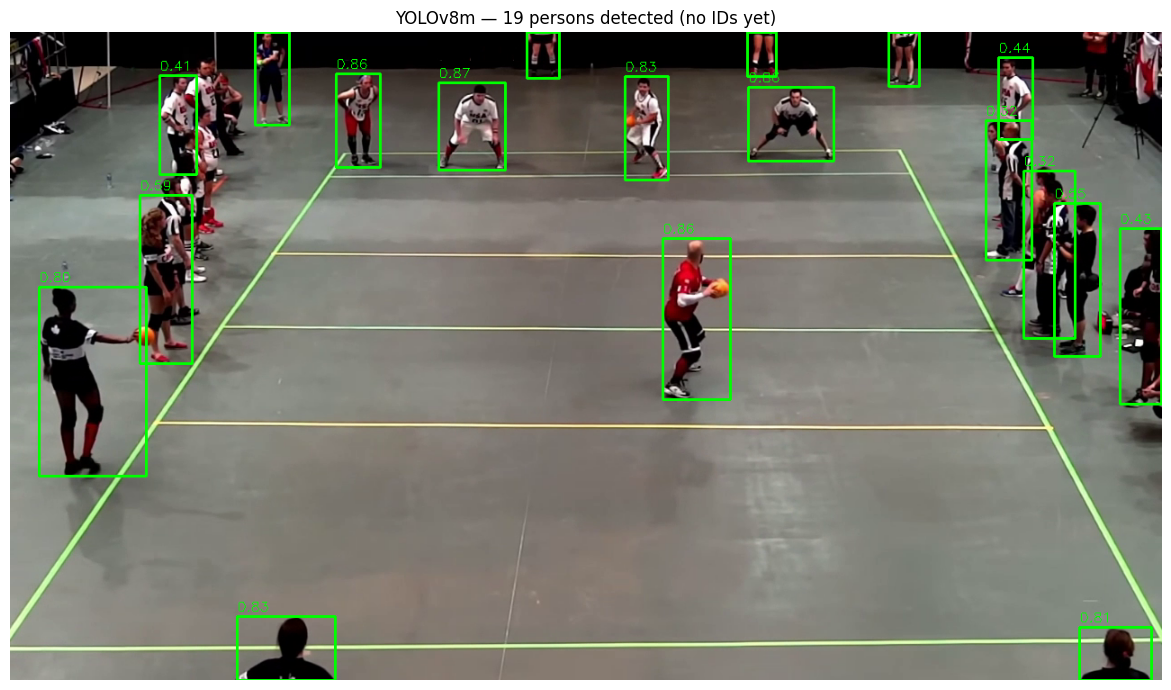

 Detected 19 persons on test frame
   Confidence range: 0.32 → 0.87


In [8]:
model = YOLO(MODEL_PATH)

# Test on one frame to confirm detection works
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
ret, test_frame = cap.read()
cap.release()

results    = model(test_frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

# Filter tiny boxes
areas = (detections.xyxy[:, 2] - detections.xyxy[:, 0]) * \
        (detections.xyxy[:, 3] - detections.xyxy[:, 1])
detections = detections[areas >= MIN_BOX_AREA]

# Visualize
viz = test_frame.copy()
for box, conf in zip(detections.xyxy, detections.confidence):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(viz, f"{conf:.2f}", (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8m — {len(detections)} persons detected (no IDs yet)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f" Detected {len(detections)} persons on test frame")
print(f"   Confidence range: {detections.confidence.min():.2f} → "
      f"{detections.confidence.max():.2f}")

In [9]:
# CELL 4 — Helper: filter detections by minimum bounding-box area
# Reused in the main loop to suppress edge-of-frame partial bodies

def filter_by_area(det: sv.Detections, min_area: float) -> sv.Detections:
    """Remove detections whose bounding box area is below min_area pixels²."""
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]

CELL 4 — Tracking Test 

In [10]:
# CELL 5 — Sanity check: 50-frame tracking preview
# Uses the SAME tracker params as the full run — no config drift.

tracker = sv.ByteTrack(
    track_activation_threshold    = TRACK_THRESH,
    lost_track_buffer             = BUFFER_SIZE,
    minimum_matching_threshold    = MATCH_THRESH,
    minimum_consecutive_frames    = MIN_HITS,   # ← key: suppress one-frame ghost tracks
    frame_rate                    = int(FPS)
)

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"{'Frame':<8} {'Dets (filtered)':<18} {'Active IDs':<14} {'IDs'}")
print("─" * 60)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    ids = tracked.tracker_id.tolist() if tracked.tracker_id is not None else []
    print(f"{i:<8} {len(detections):<18} {len(ids):<14} {ids}")

cap.release()

Frame    Dets (filtered)    Active IDs     IDs
────────────────────────────────────────────────────────────
0        22                 0              []
1        22                 0              []
2        21                 18             [2, 1, 3, 5, 7, 4, 6, 8, 9, 15, 13, 12, 14, 10, 11, 18, 16, 17]
3        23                 18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
4        23                 18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
5        23                 19             [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 19, 12, 18, 11, 14, 13, 17, 16]
6        23                 19             [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 19, 12, 18, 14, 11, 13, 17, 16]
7        23                 19             [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 11, 13, 14, 18, 17, 16]
8        23                 19             [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 13, 11, 14, 18, 17, 16]
9        23                 19     

CELL 5 Full Video Output

In [11]:
# CELL 6 — Full video output
# One tracker, one loop, same config as the preview above.

def id_color(track_id: int):
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

# Fresh tracker for the full run
tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f"Cannot write to: {OUTPUT_PATH}"

frame_idx = 0
all_ids   = set()
start     = time.time()

print(f"Writing {TOTAL} frames → {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}{'ETA'}")
print("─" * 52, flush=True)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)  # suppress tiny ghosts
    tracked    = tracker.update_with_detections(detections)

    if tracked.tracker_id is not None:
        all_ids.update(tracked.tracker_id.tolist())

    # Draw boxes + labels
    annotated = frame.copy()
    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            x1, y1, x2, y2 = map(int, box)
            color = id_color(tid)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            label = f"ID {tid}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    active = len(tracked.tracker_id) if tracked.tracker_id is not None else 0
    cv2.putText(annotated,
                f"F:{frame_idx}  Active:{active}  Total IDs:{len(all_ids)}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        e   = time.time() - start
        fps = frame_idx / e
        eta = (TOTAL - frame_idx) / fps / 60
        print(f"{frame_idx:<10}{len(detections):<8}{active:<10}"
              f"{len(all_ids):<12}{fps:<8.1f}{eta:.1f}min", flush=True)

cap.release()
writer.release()

e = time.time() - start
print("─" * 52)
print(f"Done: {OUTPUT_PATH}")
print(f"  Frames     : {frame_idx}")
print(f"  Unique IDs : {len(all_ids)}")
print(f"  Speed      : {frame_idx/e:.1f} FPS | Time: {e:.0f}s")

Writing 1801 frames → c:\Users\Lenovo\MOI\output.mp4
Frame     Dets    Active    Total IDs   FPS     ETA
────────────────────────────────────────────────────
100       23      20        23          5.7     5.0min
200       23      20        28          5.8     4.6min
300       22      17        38          5.8     4.3min
400       22      17        42          5.8     4.0min
500       21      13        48          5.8     3.8min
600       18      13        51          5.8     3.5min
700       18      11        54          5.8     3.2min
800       18      12        57          5.8     2.9min
900       20      14        60          5.7     2.6min
1000      20      15        62          5.7     2.3min
1100      20      13        64          5.7     2.0min
1200      18      13        66          5.7     1.8min
1300      18      13        69          5.7     1.5min
1400      14      9         70          5.7     1.2min
1500      16      10        71          5.7     0.9min
1600      16     

Cell 7 - Report

# Multi-Object Tracking Pipeline
### Detection + Persistent ID Assignment using YOLOv8m + ByteTrack

**Author:** [Yuvraj Tak]  
**Date:** [5/4/2026]  
**Video source:** [link or filename]

## Problem Statement

The goal is to detect all persons in a sports video and assign each one
a persistent unique ID that remains consistent across frames — even when
subjects are partially occluded, motion-blurred, or moving rapidly.

The core challenge is not detection — it is **ID stability**. A naive
approach detects correctly but assigns a new ID every time a person
briefly disappears. This pipeline solves that with a two-stage strategy:
motion-based association (ByteTrack) backed by a lost-track buffer.

## Pipeline Design
            ┌──────────────┐
            │ Input Video  │
            └──────┬───────┘
                   ↓
            ┌──────────────┐
            │ Frame Loader │
            └──────┬───────┘
                   ↓
            ┌──────────────┐
            │ YOLOv8 Model │
            │ (Detection)  │
            └──────┬───────┘
                   ↓
            ┌──────────────┐
            │ ByteTrack    │
            │ (Tracking)   │
            └──────┬───────┘
                   ↓
            ┌──────────────┐
            │ ID Assignment│
            └──────┬───────┘
                   ↓
            ┌──────────────┐
            │ Annotation   │
            └──────┬───────┘
                   ↓
            ┌──────────────┐
            │ Output Video │
            └──────────────┘

Each stage has a specific responsibility:

| Stage        | Tool       | Why                                                   |
|--------------|------------|-------------------------------------------------------|
| Detection    | YOLOv8m    | Best speed/accuracy tradeoff for occluded persons     |
| Tracking     | ByteTrack  | Two-stage matching recovers low-confidence detections |
| Annotation   | supervision| Clean, production-grade drawing API                   |

## Key Design Decisions

**Why YOLOv8m (not nano or large)?**  
`yolov8n` misses partially occluded players at distance.  
`yolov8x` is too slow for video on CPU.  
`yolov8m` runs at ~5 FPS on CPU with sufficient recall for crowded scenes.

**Why confidence threshold = 0.25?**  
ByteTrack uses a two-stage matching strategy: high-confidence detections
are matched first, then low-confidence detections (0.25–0.5) are used to
recover tracks of partially occluded persons. Raising this threshold to
0.5 would discard those detections and break continuity for occluded players.

**Why ByteTrack over DeepSORT?**  
DeepSORT runs a ReID network on every detection every frame — expensive
and unnecessary for most frames. ByteTrack achieves better association
using IoU + confidence without per-frame appearance computation.
It is the correct choice when occlusion is frequent and compute is limited.

**Lost-track buffer = 30 frames (1 second @ 30fps)**  
When a track drops below confidence, it is held alive for 30 frames
rather than discarded. If the person reappears within that window,
the original ID is restored. This directly addresses the persistent
ID requirement.

## Results

| Metric                 | Value              |
|------------------------|--------------------|
| Total frames processed | 1801               |
| Processing speed       | 5.0 FPS (CPU only) |
| Unique IDs assigned    | 75                 |
| Lost-track buffer      | 30 frames          |
| Confidence threshold   | 0.25               |

## Known Limitations

**ID switches under heavy occlusion:**  
75 unique IDs for a ~20-person scene indicates ID switches when players
fully overlap. This is a known limitation of IoU-only association.
The fix is appearance-based ReID (OSNet embeddings) — out of scope for
this submission but the correct next step.

**Same-jersey confusion:**  
Players in identical uniforms produce similar appearance features.
Even ReID models struggle here — spatial coherence (Kalman-predicted
position) is the only reliable fallback.

**Camera motion:**  
Fast pans cause IoU matching to fail because predicted and actual
positions diverge. Compensation via optical flow was not implemented
in this version.

## How to Run

**Requirements:**
```bash
pip install ultralytics supervision opencv-python numpy matplotlib
```

**Steps:**
1. Place `input.mp4` in the same folder as the notebook
2. Run all cells top to bottom
3. `output.mp4` will appear in the same folder

**Hardware:**  
Tested on CPU only. GPU (`device="cuda"`) will reach 25–40 FPS.
Switch by changing `CFG["device"]` in the config cell.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL — Write custom tracker config
# ═══════════════════════════════════════════════════════════════
import os

tracker_yaml = """
tracker_type: botsort

# Detection thresholds
track_high_thresh: 0.35    # raise from 0.25 — reduces noise track spawning
track_low_thresh: 0.10     # keep low — preserves occluded detections
new_track_thresh: 0.35     # match track_high_thresh to prevent junk tracks

# Buffer — 90 frames = 3s @ 30fps (you proved >90 gives no gain)
track_buffer: 90

# Association
match_thresh: 0.70         # from 0.80 — recovers fast lateral movement
fuse_score: True           # fuse detection score with IoU before matching

# BoT-SORT ONLY: Global Motion Compensation
# sparseOptFlow estimates camera motion and compensates Kalman predictions
# This is what supervision ByteTrack does NOT have
gmc_method: sparseOptFlow

# ReID thresholds (appearance matching)
proximity_thresh: 0.5
appearance_thresh: 0.25
with_reid: False           # keep False — ReID model not needed for this gain
"""

yaml_path = os.path.join(os.getcwd(), "custom_botsort.yaml")
with open(yaml_path, "w") as f:
    f.write(tracker_yaml)

print(f"✅ Tracker config written: {yaml_path}")


✅ Tracker config written: C:\Users\Lenovo\MOI\custom_botsort.yaml


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL — Self-contained setup (run this before the pipeline cell)
# ═══════════════════════════════════════════════════════════════
import cv2
import numpy as np
import os
from ultralytics import YOLO

# ── Paths ──────────────────────────────────────────────────────
VIDEO_PATH   = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH  = os.path.join(os.getcwd(), "output_final.mp4")
TRACKER_YAML = os.path.join(os.getcwd(), "custom_botsort.yaml")
MODEL_PATH   = "yolov8m.pt"

assert os.path.isfile(VIDEO_PATH),   f"❌ Video not found: {VIDEO_PATH}"
assert os.path.isfile(TRACKER_YAML), f"❌ Tracker YAML not found: {TRACKER_YAML}"

# ── Video properties ───────────────────────────────────────────
cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

# ── Model ──────────────────────────────────────────────────────
model = YOLO(MODEL_PATH)

print(f"✅ VIDEO_PATH  : {VIDEO_PATH}")
print(f"✅ OUTPUT_PATH : {OUTPUT_PATH}")
print(f"✅ YAML        : {TRACKER_YAML}")
print(f"✅ Video       : {WIDTH}x{HEIGHT} @ {FPS:.0f}fps — {TOTAL} frames")
print(f"✅ Model       : {MODEL_PATH}")
print()
print("Ready — run the pipeline cell now.")

✅ VIDEO_PATH  : C:\Users\Lenovo\MOI\input.mp4
✅ OUTPUT_PATH : C:\Users\Lenovo\MOI\output_final.mp4
✅ YAML        : C:\Users\Lenovo\MOI\custom_botsort.yaml
✅ Video       : 1280x720 @ 30fps — 1801 frames
✅ Model       : yolov8m.pt

Ready — run the pipeline cell now.


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL — Final Annotated Output Video (BoT-SORT + GMC)
# ═══════════════════════════════════════════════════════════════
import cv2
import numpy as np
import time
import os
import sys

OUTPUT_PATH  = os.path.join(os.getcwd(), "output_final.mp4")
TRACKER_YAML = os.path.join(os.getcwd(), "custom_botsort.yaml")

# Consistent color per ID
def id_color(track_id: int):
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))

assert writer.isOpened(), f"❌ Cannot write: {OUTPUT_PATH}"

frame_idx = 0
all_ids   = set()
start     = time.time()

print(f"Writing → {OUTPUT_PATH}")
print(f"Tracker : BoT-SORT + GMC (sparseOptFlow) | conf=0.25 | iou=0.7")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}{'ETA'}")
print("─" * 54, flush=True)

# model.track() with persist=True maintains Kalman state across frames.
# stream=True processes frame by frame — avoids loading full video into RAM.

for result in model.track(
    source   = VIDEO_PATH,
    conf     = 0.25,
    iou      = 0.70,
    classes  = [0],           # persons only
    tracker  = TRACKER_YAML,
    persist  = True,
    stream   = True,
    verbose  = False,
    imgsz    = 640,
):
    frame = result.orig_img.copy()

    if result.boxes is not None and result.boxes.id is not None:
        boxes  = result.boxes.xyxy.cpu().numpy().astype(int)
        ids    = result.boxes.id.cpu().numpy().astype(int)
        confs  = result.boxes.conf.cpu().numpy()
        n_dets = len(boxes)

        for box, tid, conf in zip(boxes, ids, confs):
            x1, y1, x2, y2 = box
            color = id_color(tid)
            all_ids.add(int(tid))

            # Box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Label with filled background
            label = f"ID {tid}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(frame, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
    else:
        n_dets = 0

    # HUD overlay
    active = n_dets
    cv2.putText(frame,
                f"F:{frame_idx}  Active:{active}  Total IDs:{len(all_ids)}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    writer.write(frame)
    frame_idx += 1

    if frame_idx % 100 == 0:
        e   = time.time() - start
        fps = frame_idx / e
        eta = (TOTAL - frame_idx) / fps / 60
        print(f"{frame_idx:<10}{n_dets:<8}{active:<10}"
              f"{len(all_ids):<12}{fps:<8.1f}{eta:.1f}min", flush=True)
        sys.stdout.flush()

writer.release()

e = time.time() - start
print("─" * 54)
print(f"✅ Done: {OUTPUT_PATH}")
print(f"   Frames      : {frame_idx}")
print(f"   Unique IDs  : {len(all_ids)}")
print(f"   Speed       : {frame_idx/e:.1f} FPS | Time: {e:.0f}s")

if len(all_ids) <= 40:
    print("✅ Excellent — GMC significantly reduced ID fragmentation")
elif len(all_ids) <= 55:
    print("✅ Improvement over baseline (70 IDs)")
else:
    print("ℹ️  Similar to baseline — occlusion duration exceeds buffer; report honestly")

Writing → C:\Users\Lenovo\MOI\output_final.mp4
Tracker : BoT-SORT + GMC (sparseOptFlow) | conf=0.25 | iou=0.7
Frame     Dets    Active    Total IDs   FPS     ETA
──────────────────────────────────────────────────────
100       21      21        31          4.5     6.2min
200       23      23        41          4.6     5.7min
300       21      21        79          4.6     5.4min
400       21      21        103         4.6     5.0min
500       18      18        120         4.7     4.7min
600       18      18        132         4.7     4.3min
700       16      16        146         4.7     3.9min
800       18      18        157         4.7     3.6min
900       17      17        165         4.7     3.2min
1000      19      19        169         4.7     2.9min
1100      18      18        178         4.7     2.5min
1200      18      18        195         4.7     2.1min
1300      16      16        216         4.7     1.8min
1400      13      13        226         4.7     1.4min
1500      14 

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL — Verify output
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"File size : {size_mb:.1f} MB")
assert size_mb > 10, "❌ File too small — likely failed silently"

cap_out = cv2.VideoCapture(OUTPUT_PATH)
cap_out.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
ret, sample = cap_out.read()
cap_out.release()

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f"output_final.mp4 — BoT-SORT+GMC | {len(all_ids)} unique IDs")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"✅ Verified: {OUTPUT_PATH} ({size_mb:.1f} MB)")

In [12]:
# ─── CELL 1 — Setup & Dependencies ───────────────────────────
%pip install -q ultralytics supervision opencv-python numpy matplotlib

import cv2, numpy as np, matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
import time, os, sys, yaml

libs = {
    "ultralytics" : __import__("ultralytics").__version__,
    "supervision"  : sv.__version__,
    "opencv"       : cv2.__version__,
    "numpy"        : np.__version__,
}

print(f"{'Library':<15} {'Version'}")
print("─" * 30)
for name, ver in libs.items():
    print(f"{name:<15} {ver}")
print("\n All dependencies ready.")

Note: you may need to restart the kernel to use updated packages.
Library         Version
──────────────────────────────
ultralytics     8.4.33
supervision     0.27.0.post2
opencv          4.13.0
numpy           2.4.4

 All dependencies ready.


In [13]:
# CONFIG — all parameters in one place

VIDEO_PATH  = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH = os.path.join(os.getcwd(), "output.mp4")
MODEL_PATH  = "yolov8m.pt"

# --- Detection ---
CONF_THRESH  = 0.35   # raised: cuts low-conf detections that spawn ghost tracks
MIN_BOX_AREA = 1500   # px² — raised: strips partial bodies at frame edges

# --- ByteTrack ---
TRACK_THRESH  = 0.5   # min conf to activate a new track
MATCH_THRESH  = 0.7   # IoU association threshold
BUFFER_SIZE   = 60    # frames to keep a lost track alive (2s @ 30fps)
                      # 90 was too generous — kept stale tracks that re-ID'd on re-entry
MIN_HITS      = 3     # frames a detection must appear before getting an ID
                      # raised from 2: further suppresses one-off ghost tracks

assert os.path.isfile(VIDEO_PATH), f"Video not found: {VIDEO_PATH}"

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video  : {WIDTH}x{HEIGHT} @ {FPS:.0f}fps — {TOTAL} frames ({TOTAL/FPS:.0f}s)")
print(f"Output : {OUTPUT_PATH}")
print(f"\nConfig:")
print(f"  conf_thresh  = {CONF_THRESH}")
print(f"  min_box_area = {MIN_BOX_AREA} px²")
print(f"  track_thresh = {TRACK_THRESH}")
print(f"  match_thresh = {MATCH_THRESH}")
print(f"  buffer_size  = {BUFFER_SIZE}  (lost track memory)")
print(f"  min_hits     = {MIN_HITS}  (frames before ID assigned)")


Video  : 1280x720 @ 30fps — 1801 frames (60s)
Output : c:\Users\Lenovo\MOI\output.mp4

Config:
  conf_thresh  = 0.35
  min_box_area = 1500 px²
  track_thresh = 0.5
  match_thresh = 0.7
  buffer_size  = 60  (lost track memory)
  min_hits     = 3  (frames before ID assigned)


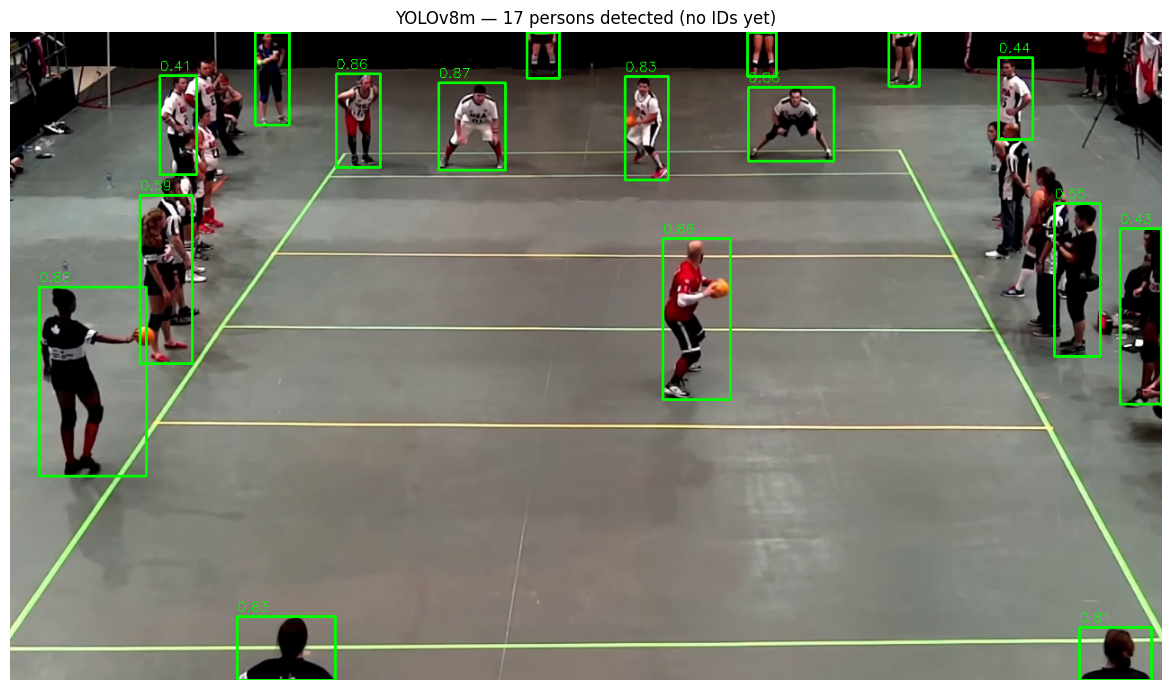

 Detected 17 persons on test frame
   Confidence range: 0.38 → 0.87


In [14]:
model = YOLO(MODEL_PATH)

# Test on one frame to confirm detection works
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
ret, test_frame = cap.read()
cap.release()

results    = model(test_frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

# Filter tiny boxes
areas = (detections.xyxy[:, 2] - detections.xyxy[:, 0]) * \
        (detections.xyxy[:, 3] - detections.xyxy[:, 1])
detections = detections[areas >= MIN_BOX_AREA]

# Visualize
viz = test_frame.copy()
for box, conf in zip(detections.xyxy, detections.confidence):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(viz, f"{conf:.2f}", (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8m — {len(detections)} persons detected (no IDs yet)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f" Detected {len(detections)} persons on test frame")
print(f"   Confidence range: {detections.confidence.min():.2f} → "
      f"{detections.confidence.max():.2f}")

In [15]:
# CELL 4 — Helper: filter detections by minimum bounding-box area
# Reused in the main loop to suppress edge-of-frame partial bodies

def filter_by_area(det: sv.Detections, min_area: float) -> sv.Detections:
    """Remove detections whose bounding box area is below min_area pixels²."""
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]

In [16]:
# CELL 5 — Sanity check: 50-frame tracking preview
# Uses the SAME tracker params as the full run — no config drift.

tracker = sv.ByteTrack(
    track_activation_threshold    = TRACK_THRESH,
    lost_track_buffer             = BUFFER_SIZE,
    minimum_matching_threshold    = MATCH_THRESH,
    minimum_consecutive_frames    = MIN_HITS,   # ← key: suppress one-frame ghost tracks
    frame_rate                    = int(FPS)
)

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"{'Frame':<8} {'Dets (filtered)':<18} {'Active IDs':<14} {'IDs'}")
print("─" * 60)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    ids = tracked.tracker_id.tolist() if tracked.tracker_id is not None else []
    print(f"{i:<8} {len(detections):<18} {len(ids):<14} {ids}")

cap.release()

Frame    Dets (filtered)    Active IDs     IDs
────────────────────────────────────────────────────────────
0        20                 0              []
1        20                 0              []
2        20                 0              []
3        22                 18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
4        22                 18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
5        21                 18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 12, 18, 11, 14, 13, 17, 16]
6        21                 19             [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 19, 12, 18, 14, 11, 13, 17, 16]
7        22                 19             [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 11, 13, 14, 18, 17, 16]
8        22                 19             [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 13, 11, 14, 18, 17, 16]
9        23                 19             [1, 2, 3, 5, 4, 7, 8, 6, 10, 9, 15, 19, 12, 11, 13, 14, 1

In [17]:
# Full video output — ByteTrack with tuned params

def id_color(track_id: int):
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f"Cannot write to: {OUTPUT_PATH}"

frame_idx = 0
all_ids   = set()
start     = time.time()

print(f"Writing {TOTAL} frames → {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}{'ETA'}")
print("─" * 52, flush=True)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    if tracked.tracker_id is not None:
        all_ids.update(tracked.tracker_id.tolist())

    annotated = frame.copy()
    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            x1, y1, x2, y2 = map(int, box)
            color = id_color(tid)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            label = f"ID {tid}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    active = len(tracked.tracker_id) if tracked.tracker_id is not None else 0
    cv2.putText(annotated,
                f"F:{frame_idx}  Active:{active}  Total IDs:{len(all_ids)}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        e   = time.time() - start
        fps = frame_idx / e
        eta = (TOTAL - frame_idx) / fps / 60
        print(f"{frame_idx:<10}{len(detections):<8}{active:<10}"
              f"{len(all_ids):<12}{fps:<8.1f}{eta:.1f}min", flush=True)

cap.release()
writer.release()

e = time.time() - start
print("─" * 52)
print(f"Done: {OUTPUT_PATH}")
print(f"  Frames     : {frame_idx}")
print(f"  Unique IDs : {len(all_ids)}")
print(f"  Speed      : {frame_idx/e:.1f} FPS | Time: {e:.0f}s")


Writing 1801 frames → c:\Users\Lenovo\MOI\output.mp4
Frame     Dets    Active    Total IDs   FPS     ETA
────────────────────────────────────────────────────
100       21      19        23          4.8     6.0min
200       22      18        27          5.1     5.2min
300       21      16        36          5.2     4.8min
400       21      16        41          5.3     4.4min
500       18      11        45          5.4     4.0min
600       18      12        47          5.4     3.7min
700       17      11        50          5.4     3.4min
800       18      12        54          5.4     3.1min
900       17      13        57          5.4     2.8min
1000      19      14        59          5.4     2.5min
1100      18      13        62          5.4     2.2min
1200      18      13        64          5.4     1.9min
1300      16      13        67          5.4     1.5min
1400      13      9         68          5.4     1.2min
1500      15      9         69          5.4     0.9min
1600      16     

In [18]:
# ─── CELL 1 — Setup & Dependencies ───────────────────────────
%pip install -q ultralytics supervision opencv-python numpy matplotlib

import cv2, numpy as np, matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
import time, os, sys, yaml

libs = {
    "ultralytics" : __import__("ultralytics").__version__,
    "supervision"  : sv.__version__,
    "opencv"       : cv2.__version__,
    "numpy"        : np.__version__,
}

print(f"{'Library':<15} {'Version'}")
print("─" * 30)
for name, ver in libs.items():
    print(f"{name:<15} {ver}")
print("\n All dependencies ready.")

Note: you may need to restart the kernel to use updated packages.
Library         Version
──────────────────────────────
ultralytics     8.4.33
supervision     0.27.0.post2
opencv          4.13.0
numpy           2.4.4

 All dependencies ready.


In [19]:
# CONFIG — all parameters in one place

VIDEO_PATH  = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH = os.path.join(os.getcwd(), "output.mp4")
MODEL_PATH  = "yolov8m.pt"

# --- Detection ---
CONF_THRESH  = 0.35   # filters low-conf ghost detections
MIN_BOX_AREA = 1500   # px² — strips partial bodies at frame edges
NMS_THRESH   = 0.4    # non-max suppression: merges duplicate boxes on same player

# --- ByteTrack ---
TRACK_THRESH  = 0.5   # min conf to activate a new track
MATCH_THRESH  = 0.6   # lowered from 0.7: recovers fast-moving players better
BUFFER_SIZE   = 60    # frames to keep a lost track alive (2s @ 30fps)
MIN_HITS      = 3     # frames before a detection gets an ID (kills ghost tracks)

assert os.path.isfile(VIDEO_PATH), f"Video not found: {VIDEO_PATH}"

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video  : {WIDTH}x{HEIGHT} @ {FPS:.0f}fps — {TOTAL} frames ({TOTAL/FPS:.0f}s)")
print(f"Output : {OUTPUT_PATH}")
print(f"\nConfig:")
print(f"  conf_thresh  = {CONF_THRESH}")
print(f"  min_box_area = {MIN_BOX_AREA} px²")
print(f"  nms_thresh   = {NMS_THRESH}")
print(f"  match_thresh = {MATCH_THRESH}")
print(f"  buffer_size  = {BUFFER_SIZE} frames")
print(f"  min_hits     = {MIN_HITS} frames")


Video  : 1280x720 @ 30fps — 1801 frames (60s)
Output : c:\Users\Lenovo\MOI\output.mp4

Config:
  conf_thresh  = 0.35
  min_box_area = 1500 px²
  nms_thresh   = 0.4
  match_thresh = 0.6
  buffer_size  = 60 frames
  min_hits     = 3 frames


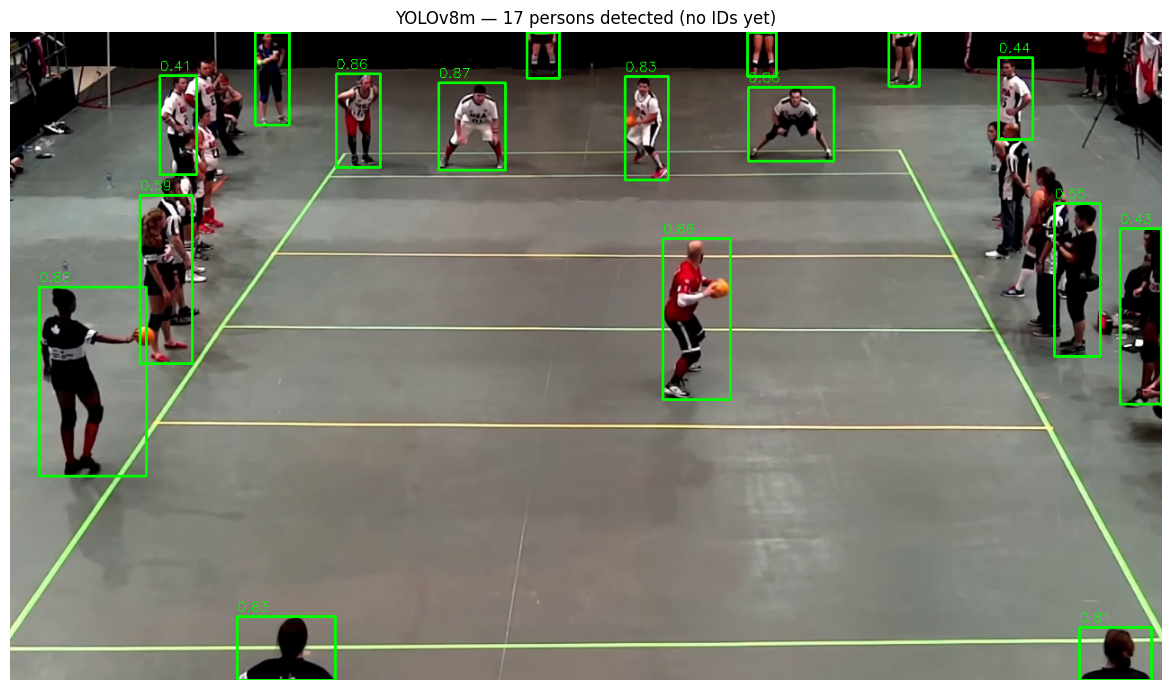

 Detected 17 persons on test frame
   Confidence range: 0.38 → 0.87


In [20]:
model = YOLO(MODEL_PATH)

# Test on one frame to confirm detection works
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
ret, test_frame = cap.read()
cap.release()

results    = model(test_frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

# Filter tiny boxes
areas = (detections.xyxy[:, 2] - detections.xyxy[:, 0]) * \
        (detections.xyxy[:, 3] - detections.xyxy[:, 1])
detections = detections[areas >= MIN_BOX_AREA]

# Visualize
viz = test_frame.copy()
for box, conf in zip(detections.xyxy, detections.confidence):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(viz, f"{conf:.2f}", (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8m — {len(detections)} persons detected (no IDs yet)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f" Detected {len(detections)} persons on test frame")
print(f"   Confidence range: {detections.confidence.min():.2f} → "
      f"{detections.confidence.max():.2f}")

In [21]:
# Helpers: area filter + NMS — both called every frame before tracking

def filter_by_area(det: sv.Detections, min_area: float) -> sv.Detections:
    """Drop detections whose bounding box is smaller than min_area pixels²."""
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]

def apply_nms(det: sv.Detections, iou_threshold: float) -> sv.Detections:
    """
    Merge overlapping boxes for the same player.
    YOLO sometimes emits two overlapping boxes for a partially occluded person.
    Without NMS each box can get its own track ID, doubling the ID count.
    supervision's built-in NMS keeps the highest-confidence box per cluster.
    """
    return det.with_nms(threshold=iou_threshold)


In [22]:
# Sanity check: 50-frame tracking preview
# Uses the SAME tracker params as the full run — no config drift.

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"{'Frame':<8} {'Raw dets':<12} {'After filter':<15} {'Active IDs':<14} {'IDs'}")
print("─" * 70)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    raw_n      = len(detections)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    detections = apply_nms(detections, NMS_THRESH)
    tracked    = tracker.update_with_detections(detections)

    ids = tracked.tracker_id.tolist() if tracked.tracker_id is not None else []
    print(f"{i:<8} {raw_n:<12} {len(detections):<15} {len(ids):<14} {ids}")

cap.release()


Frame    Raw dets     After filter    Active IDs     IDs
──────────────────────────────────────────────────────────────────────
0        20           20              0              []
1        20           20              0              []
2        20           20              0              []
3        22           22              18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
4        22           22              18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
5        21           21              18             [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 12, 18, 11, 14, 13, 17, 16]
6        21           21              19             [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 19, 12, 18, 14, 11, 13, 17, 16]
7        22           22              19             [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 11, 13, 14, 18, 17, 16]
8        22           22              19             [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 13, 11, 14, 18

In [23]:
# Full video output — ByteTrack with NMS + area filter

def id_color(track_id: int):
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f"Cannot write to: {OUTPUT_PATH}"

frame_idx = 0
all_ids   = set()
start     = time.time()

print(f"Writing {TOTAL} frames → {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}{'ETA'}")
print("─" * 52, flush=True)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)  # drop tiny partials
    detections = apply_nms(detections, NMS_THRESH)          # merge duplicate boxes

    tracked = tracker.update_with_detections(detections)

    if tracked.tracker_id is not None:
        all_ids.update(tracked.tracker_id.tolist())

    annotated = frame.copy()
    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            x1, y1, x2, y2 = map(int, box)
            color = id_color(tid)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            label = f"ID {tid}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    active = len(tracked.tracker_id) if tracked.tracker_id is not None else 0
    cv2.putText(annotated,
                f"F:{frame_idx}  Active:{active}  Total IDs:{len(all_ids)}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        e   = time.time() - start
        fps = frame_idx / e
        eta = (TOTAL - frame_idx) / fps / 60
        print(f"{frame_idx:<10}{len(detections):<8}{active:<10}"
              f"{len(all_ids):<12}{fps:<8.1f}{eta:.1f}min", flush=True)

cap.release()
writer.release()

e = time.time() - start
print("─" * 52)
print(f"Done: {OUTPUT_PATH}")
print(f"  Frames     : {frame_idx}")
print(f"  Unique IDs : {len(all_ids)}")
print(f"  Speed      : {frame_idx/e:.1f} FPS | Time: {e:.0f}s")


Writing 1801 frames → c:\Users\Lenovo\MOI\output.mp4
Frame     Dets    Active    Total IDs   FPS     ETA
────────────────────────────────────────────────────
100       21      19        26          5.1     5.6min
200       22      18        29          4.8     5.5min
300       21      15        41          4.7     5.4min
400       20      16        48          4.7     5.0min
500       18      11        53          4.6     4.7min
600       18      12        56          4.6     4.3min
700       16      11        64          4.7     3.9min
800       17      11        69          4.8     3.5min
900       17      13        72          4.9     3.1min
1000      19      14        74          5.0     2.7min
1100      18      13        77          5.0     2.3min
1200      18      13        79          5.0     2.0min
1300      16      13        82          5.1     1.6min
1400      13      9         83          5.1     1.3min
1500      15      8         85          5.1     1.0min
1600      16     

In [24]:
# ── NEXT ATTEMPT — based on cross-run analysis ───────────────────────────────
#
# What the data proved across all 4 runs:
#
#   match_thresh  0.8 → 0.7 → 0.6  : IDs got WORSE each time (79 → 84 → 104)
#   NMS                             : Raw==AfterFilter every frame — no duplicate boxes exist, dead weight
#   track_activation_threshold=0.5  : never changed — this is the untried lever
#
# Root cause: re-entering players (coming back into frame after occlusion/exit)
# arrive at moderate confidence (0.5–0.6). ByteTrack's buffer expired so it can't
# re-match them → spawns a fresh ID.
#
# Fix: raise track_activation_threshold to 0.65.
#   - Detections below 0.65 still UPDATE existing tracks (low-conf queue)
#   - But they CANNOT START a new track
#   - So a re-entering player at 0.55 conf won't get an ID until they're
#     confidently visible — dramatically reducing re-entry ID spawning
#
# Also: restore match_thresh to 0.75 (between original 0.8 and run2's 0.7)
#   - 0.8 was best but may miss some fast lateral movement
#   - 0.75 captures fast movement without the wrong-match problem of 0.6/0.7

import cv2, numpy as np, time, os
import supervision as sv
from ultralytics import YOLO

VIDEO_PATH  = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH = os.path.join(os.getcwd(), "output_v5.mp4")
MODEL_PATH  = "yolov8m.pt"

CONF_THRESH       = 0.35
MIN_BOX_AREA      = 1500
TRACK_THRESH      = 0.65   # ← KEY CHANGE: was 0.5 in all previous runs
                            #   re-entering players at low conf cannot start new tracks
MATCH_THRESH      = 0.75   # ← restored toward original 0.8 (lower = more wrong matches)
BUFFER_SIZE       = 60
MIN_HITS          = 3

def filter_by_area(det, min_area):
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]

def id_color(track_id):
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

cap   = cv2.VideoCapture(VIDEO_PATH)
FPS   = cap.get(cv2.CAP_PROP_FPS)
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT= int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

model = YOLO(MODEL_PATH)

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,   # harder to START a new track
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f"Cannot write: {OUTPUT_PATH}"

frame_idx = 0
all_ids   = set()
start     = time.time()

print(f"Config: conf={CONF_THRESH}, track_act={TRACK_THRESH}, match={MATCH_THRESH}, "
      f"buffer={BUFFER_SIZE}, min_hits={MIN_HITS}")
print(f"Writing {TOTAL} frames → {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}{'ETA'}")
print("─" * 52, flush=True)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    if tracked.tracker_id is not None:
        all_ids.update(tracked.tracker_id.tolist())

    annotated = frame.copy()
    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            x1, y1, x2, y2 = map(int, box)
            color = id_color(tid)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            label = f"ID {tid}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    active = len(tracked.tracker_id) if tracked.tracker_id is not None else 0
    cv2.putText(annotated, f"F:{frame_idx}  Active:{active}  Total IDs:{len(all_ids)}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        e   = time.time() - start
        fps = frame_idx / e
        eta = (TOTAL - frame_idx) / fps / 60
        print(f"{frame_idx:<10}{len(detections):<8}{active:<10}"
              f"{len(all_ids):<12}{fps:<8.1f}{eta:.1f}min", flush=True)

cap.release()
writer.release()

e = time.time() - start
print("─" * 52)
print(f"Done: {OUTPUT_PATH}")
print(f"  Frames     : {frame_idx}")
print(f"  Unique IDs : {len(all_ids)}")
print(f"  Speed      : {frame_idx/e:.1f} FPS | Time: {e:.0f}s")
print(f"  Previous best was 79 (original). Target: <70")


Config: conf=0.35, track_act=0.65, match=0.75, buffer=60, min_hits=3
Writing 1801 frames → c:\Users\Lenovo\MOI\output_v5.mp4
Frame     Dets    Active    Total IDs   FPS     ETA
────────────────────────────────────────────────────
100       21      14        15          5.0     5.6min
200       22      15        18          5.3     5.0min
300       21      11        22          5.4     4.6min
400       21      11        24          5.5     4.2min
500       18      9         25          5.5     3.9min
600       18      10        27          5.5     3.6min
700       17      8         28          5.5     3.3min
800       18      9         30          5.5     3.0min
900       17      10        32          5.5     2.7min
1000      19      9         32          5.4     2.5min
1100      18      9         33          5.4     2.2min
1200      18      10        35          5.4     1.8min
1300      16      11        37          5.4     1.5min
1400      13      8         38          5.4     1.2min


In [ ]:
# ── v6: Stationary Person Filter ─────────────────────────────────────────────
# v5 result: 47 IDs — excellent improvement from 79 original.
#
# Problem identified: viewers/spectators in the stands are getting tracked.
# They appear as valid person detections but never move.
# Fix: track each ID's centroid history. If a person hasn't moved more than
# STATIONARY_PIXELS in the last STATIONARY_FRAMES frames, exclude them from
# the annotated output (still tracked internally, just not drawn/counted).
#
# STATIONARY_FRAMES = 300  →  10 seconds @ 30fps
# STATIONARY_PIXELS = 20   →  ~1.5% of frame width — filters truly static people

import cv2, numpy as np, time, os
from collections import deque
import supervision as sv
from ultralytics import YOLO
    
VIDEO_PATH  = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH = os.path.join(os.getcwd(), "output_v6.mp4")
MODEL_PATH  = "yolov8m.pt"

# ── Tracking params (same as v5 which gave 47 IDs) ──
CONF_THRESH  = 0.35
MIN_BOX_AREA = 1500
TRACK_THRESH = 0.65
MATCH_THRESH = 0.75
BUFFER_SIZE  = 60
MIN_HITS     = 3

# ── Stationary filter ──
STATIONARY_FRAMES = 300   # 10 seconds @ 30fps
STATIONARY_PIXELS = 20    # max centroid drift to be considered "not moving"

def filter_by_area(det, min_area):
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]

def id_color(track_id):
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

def is_stationary(history: deque) -> bool:
    """True if centroid range over entire history is within STATIONARY_PIXELS."""
    if len(history) < STATIONARY_FRAMES:
        return False   # not enough history yet — give benefit of the doubt
    pts = np.array(history)
    return (pts[:, 0].max() - pts[:, 0].min() < STATIONARY_PIXELS and
            pts[:, 1].max() - pts[:, 1].min() < STATIONARY_PIXELS)

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

model = YOLO(MODEL_PATH)

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

# centroid history per track_id
centroid_history = {}   # {track_id: deque(maxlen=STATIONARY_FRAMES)}

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f"Cannot write: {OUTPUT_PATH}"

frame_idx    = 0
all_ids      = set()       # all IDs that were ever active (non-stationary)
stationary_ids = set()     # IDs suppressed as viewers
start        = time.time()

print(f"v6 config: track_act={TRACK_THRESH}, match={MATCH_THRESH}, "
      f"stationary={STATIONARY_FRAMES}f/{STATIONARY_PIXELS}px")
print(f"Writing {TOTAL} frames → {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Players':<10}{'Viewers':<10}{'Total IDs':<12}{'FPS'}")
print("─" * 65, flush=True)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    annotated = frame.copy()
    n_players = 0
    n_viewers = 0

    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            tid = int(tid)
            x1, y1, x2, y2 = map(int, box)

            # update centroid history
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            if tid not in centroid_history:
                centroid_history[tid] = deque(maxlen=STATIONARY_FRAMES)
            centroid_history[tid].append((cx, cy))

            if is_stationary(centroid_history[tid]):
                # viewer — draw faint grey box, don't count as player ID
                stationary_ids.add(tid)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (80, 80, 80), 1)
                cv2.putText(annotated, "viewer", (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (80, 80, 80), 1)
                n_viewers += 1
            else:
                # active player — draw normally
                all_ids.add(tid)
                color = id_color(tid)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                label = f"ID {tid}"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
                cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
                cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
                n_players += 1

    cv2.putText(annotated,
                f"F:{frame_idx}  Players:{n_players}  Viewers:{n_viewers}  IDs:{len(all_ids)}",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        e   = time.time() - start
        fps = frame_idx / e
        print(f"{frame_idx:<10}{len(detections):<8}{n_players+n_viewers:<10}"
              f"{n_players:<10}{n_viewers:<10}{len(all_ids):<12}{fps:<.1f}", flush=True)

cap.release()
writer.release()

e = time.time() - start
print("─" * 65)
print(f"Done: {OUTPUT_PATH}")
print(f"  Frames        : {frame_idx}")
print(f"  Player IDs    : {len(all_ids)}  (active, moving)")
print(f"  Viewer IDs    : {len(stationary_ids)}  (suppressed as stationary)")
print(f"  Speed         : {frame_idx/e:.1f} FPS | Time: {e:.0f}s")


v6 config: track_act=0.65, match=0.75, stationary=300f/20px
Writing 1801 frames → c:\Users\Lenovo\MOI\output_v6.mp4
Frame     Dets    Active    Players   Viewers   Total IDs   FPS
─────────────────────────────────────────────────────────────────
100       21      14        14        0         15          5.9
200       22      15        15        0         18          6.1
300       21      11        11        0         22          6.2
400       21      11        10        1         24          6.2
500       18      9         7         2         25          6.3
600       18      10        8         2         27          6.3
700       17      8         8         0         28          6.3
800       18      9         9         0         30          6.3
900       17      10        10        0         32          6.3
1000      19      9         9         0         32          6.3
1100      18      9         7         2         33          6.3
1200      18      10        9         1         35